# 02. Silver Label Modeling

This notebook compares several supervised models using `cluster_number == 1` as a silver label.

The performance reported here is not real viewbot detection performance. It only measures how well each model reproduces the KMeans-based suspicious signal.

## Project Framing

There is no verified ground-truth label for actual viewbot usage. Therefore, this project should not claim to automatically prove viewbot usage.

The practical goal is to reduce the number of broadcasts that a human reviewer must inspect. The model produces suspiciousness scores and review candidates, not final judgments.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_fscore_support,
    confusion_matrix,
)
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

RANDOM_STATE = 42

## 1. Load Data

In [2]:
from pathlib import Path

def find_project_root(start=None):
    """Find the project root from either the root folder or the notebooks folder."""
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / 'csv' / 'session_summary_processed.csv').exists():
            return p
    raise FileNotFoundError('Could not find csv/session_summary_processed.csv. Run this notebook from the project folder.')

PROJECT_ROOT = find_project_root()
CSV_DIR = PROJECT_ROOT / 'csv'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

PROJECT_ROOT

WindowsPath('c:/Users/82103/OneDrive/바탕 화면/SNU_2026-1/데이터마이닝/플젝/최종모델')

In [3]:
session = pd.read_csv(CSV_DIR / 'session_summary_processed.csv')
session['silver_suspicious'] = (session['cluster_number'] == 1).astype(int)

print(session.shape)
print(session['silver_suspicious'].value_counts(normalize=True).rename('ratio'))
session.head()

(1954, 22)
silver_suspicious
0   0.9432
1   0.0568
Name: ratio, dtype: float64


,run_id,broad_no,session_key,user_id,category_id,n,start,end,viewer_med,viewer_max,chat_mean,unique_mean,zero_rate,zrun_max,gap_med,gap_max,log_viewer,log_chat,log_unique,log_zrun,cluster_number,silver_suspicious
0,31,18296919,31_18296919,7de18e974bc4bbbe6737d941b72aa2f8,던전앤파이터,119,2026-04-14 17:00:00,2026-04-14 19:00:00,221.0000,258.0000,0.2101,0.1092,0.8908,9,5.3936,5.5568,5.4027,0.1907,0.1037,2.3026,1,1
1,31,18350777,31_18350777,b628d1039a84ecc703804e17acee2eb3,리그 오브 레전드,121,2026-04-14 17:00:00,2026-04-14 19:00:00,235.0000,288.0000,7.6116,4.7025,0.0909,2,3.4500,5.5759,5.4638,2.1531,1.7409,1.0986,0,0
2,31,18351042,31_18351042,d29db9ee45bf3b5e5b099c6b3c54b443,로스트아크,119,2026-04-14 17:00:00,2026-04-14 18:58:00,333.0000,383.0000,11.1681,6.8824,0.0252,2,3.5041,5.9108,5.8111,2.4988,2.0646,1.0986,0,0
3,31,18351670,31_18351670,dcfd3c7cf3c05b41306a4cc249ad5c9f,붉은사막,117,2026-04-14 17:00:00,2026-04-14 19:00:00,135.0000,159.0000,2.5641,1.8291,0.1624,2,3.7992,5.0370,4.9127,1.2709,1.0399,1.0986,0,0
4,31,18352554,31_18352554,14780be344c96ad0c272b51d0605dedb,로스트아크,121,2026-04-14 17:00:00,2026-04-14 19:00:00,361.0000,389.0000,39.3802,23.3140,0.0000,0,2.2744,3.4714,5.8916,3.6983,3.1911,0.0000,0,0


## 2. Feature Set

Only session-level summary features are used. Label columns and identifiers such as `cluster_number` and `session_key` are excluded from the model features.

Because the silver label was also created from similar session features, strong performance must be interpreted as silver-label reproduction, not confirmed viewbot detection.

In [4]:
feature_cols = [
    'n',
    'viewer_med', 'viewer_max',
    'chat_mean', 'unique_mean',
    'zero_rate', 'zrun_max',
    'gap_med', 'gap_max',
    'log_viewer', 'log_chat', 'log_unique', 'log_zrun',
]

X = session[feature_cols].copy()
y = session['silver_suspicious'].copy()

print('X:', X.shape)
print('positive ratio:', y.mean())
X.describe().T

X: (1954, 13)
positive ratio: 0.05680655066530194


,count,mean,std,min,25%,50%,75%,max
n,"1,954.0000",105.8644,30.6662,10.0000,114.2500,121.0000,122.0000,122.0000
viewer_med,"1,954.0000","1,752.7738","5,688.3475",48.0000,299.0000,574.0000,"1,275.7500","131,402.0000"
viewer_max,"1,954.0000","2,191.4800","7,779.1605",68.0000,359.2500,702.5000,"1,558.0000","172,140.0000"
chat_mean,"1,954.0000",49.0391,73.6239,0.0174,9.2828,22.9415,54.4938,866.3288
unique_mean,"1,954.0000",27.1702,39.6188,0.0174,6.0848,13.8512,30.2736,545.6849
zero_rate,"1,954.0000",0.0516,0.1308,0.0000,0.0000,0.0000,0.0327,0.9826
zrun_max,"1,954.0000",1.3690,3.8187,0.0000,0.0000,0.0000,1.0000,52.0000
gap_med,"1,954.0000",3.4676,0.8989,0.8668,2.8456,3.4259,3.9931,7.5491
gap_max,"1,954.0000",5.4289,1.0100,1.9938,4.7622,5.4172,6.0975,9.9020
log_viewer,"1,954.0000",6.4809,1.1977,3.8918,5.7038,6.3544,7.1521,11.7860


## 3. Evaluation Metrics

Accuracy is not useful for this imbalanced setting. The positive class is rare.

We focus on:

- `PR-AUC`: ranking quality under class imbalance
- `ROC-AUC`: overall separability
- `precision@k`: how many silver positives appear in the top-k review candidates
- `recall@k`: how many silver positives are recovered in the top-k set
- `F2`: a threshold metric that weights recall more than precision

In [5]:
def precision_recall_at_k(y_true, score, k):
    y_true = np.asarray(y_true)
    score = np.asarray(score)
    k = int(max(1, min(k, len(y_true))))
    idx = np.argsort(score)[::-1][:k]
    precision = y_true[idx].mean()
    recall = y_true[idx].sum() / max(1, y_true.sum())
    return precision, recall


def evaluate_scores(y_true, score, threshold=0.5):
    y_true = np.asarray(y_true)
    score = np.asarray(score)
    pred = (score >= threshold).astype(int)
    precision, recall, f2, _ = precision_recall_fscore_support(
        y_true, pred, beta=2, average='binary', zero_division=0
    )
    k = int(max(1, y_true.sum()))
    p_at_k, r_at_k = precision_recall_at_k(y_true, score, k)
    return {
        'pr_auc': average_precision_score(y_true, score),
        'roc_auc': roc_auc_score(y_true, score) if len(np.unique(y_true)) == 2 else np.nan,
        'precision_at_pos_k': p_at_k,
        'recall_at_pos_k': r_at_k,
        'precision_at_0.5': precision,
        'recall_at_0.5': recall,
        'f2_at_0.5': f2,
    }

## 4. Model Definitions

In [6]:
def make_pipeline(model, scale=True):
    steps = [
        ('imputer', SimpleImputer(strategy='median')),
    ]
    if scale:
        steps.append(('scaler', RobustScaler()))
    steps.append(('model', model))
    return Pipeline(steps)

models = {
    'logistic_balanced': make_pipeline(LogisticRegression(max_iter=5000, class_weight='balanced', random_state=RANDOM_STATE)),
    'gaussian_nb': make_pipeline(GaussianNB()),
    'decision_tree_depth3': make_pipeline(DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=RANDOM_STATE), scale=False),
    'random_forest_balanced': make_pipeline(RandomForestClassifier(
        n_estimators=400,
        max_depth=5,
        min_samples_leaf=5,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ), scale=False),
    'gradient_boosting': make_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE), scale=False),
    'linear_svc_calibrated': make_pipeline(CalibratedClassifierCV(
        estimator=LinearSVC(C=1.0, class_weight='balanced', random_state=RANDOM_STATE, max_iter=10000),
        cv=3,
    )),
}

list(models)

['logistic_balanced',
 'gaussian_nb',
 'decision_tree_depth3',
 'random_forest_balanced',
 'gradient_boosting',
 'linear_svc_calibrated']

## 5. Hold-out Test

A single stratified train/test split gives a quick first look.

This should not be the final evidence because the result can be sensitive to which sessions fall into the test set.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

holdout_rows = []
fitted_models = {}

for name, pipe in models.items():
    model = clone(pipe)
    model.fit(X_train, y_train)
    score = model.predict_proba(X_test)[:, 1]
    row = {'model': name, **evaluate_scores(y_test, score)}
    holdout_rows.append(row)
    fitted_models[name] = model

holdout_result = pd.DataFrame(holdout_rows).sort_values('pr_auc', ascending=False)
holdout_result

,model,pr_auc,roc_auc,precision_at_pos_k,recall_at_pos_k,precision_at_0.5,recall_at_0.5,f2_at_0.5
0,logistic_balanced,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,decision_tree_depth3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,gradient_boosting,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,random_forest_balanced,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,linear_svc_calibrated,1.0000,1.0000,1.0000,1.0000,1.0000,0.8636,0.8879
1,gaussian_nb,0.9031,0.9966,0.9091,0.9091,0.3492,1.0000,0.7285


## 6. Repeated Stratified K-Fold Cross Validation

Cross-validation is more important than the single hold-out result. We report both mean and standard deviation across folds to check stability.

In [8]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
cv_rows = []

for model_name, pipe in models.items():
    for fold, (tr, te) in enumerate(cv.split(X, y), start=1):
        model = clone(pipe)
        model.fit(X.iloc[tr], y.iloc[tr])
        score = model.predict_proba(X.iloc[te])[:, 1]
        metrics = evaluate_scores(y.iloc[te], score)
        cv_rows.append({'model': model_name, 'fold': fold, **metrics})

cv_result = pd.DataFrame(cv_rows)
cv_summary = (
    cv_result
    .groupby('model')
    .agg(['mean', 'std'])
    .sort_values(('pr_auc', 'mean'), ascending=False)
)
cv_summary

fold        pr_auc        roc_auc         \
                         mean    std   mean    std    mean    std   
model                                                               
random_forest_balanced 8.0000 4.4721 0.9993 0.0017  1.0000 0.0001   
logistic_balanced      8.0000 4.4721 0.9987 0.0038  0.9999 0.0003   
linear_svc_calibrated  8.0000 4.4721 0.9933 0.0109  0.9994 0.0011   
decision_tree_depth3   8.0000 4.4721 0.9861 0.0257  0.9954 0.0091   
gradient_boosting      8.0000 4.4721 0.9861 0.0257  0.9954 0.0091   
gaussian_nb            8.0000 4.4721 0.9409 0.0441  0.9930 0.0105   

                       precision_at_pos_k        recall_at_pos_k         \
                                     mean    std            mean    std   
model                                                                     
random_forest_balanced             0.9910 0.0186          0.9910 0.0186   
logistic_balanced                  0.9910 0.0253          0.9910 0.0253   
linear_svc_calibrated              0.9642 0.0302          0.9642 0.0302   
decision_tree_depth3               0.9851 0.0278          0.9851 0.0278   
gradient_boosting                  0.9851 0.0278          0.9851 0.0278   
gaussian_nb                        0.9248 0.0372          0.9248 0.0372   

                       precision_at_0.5        recall_at_0.5        f2_at_0.5  \
                                   mean    std          mean    std      mean   
model                                                                           
random_forest_balanced           0.9968 0.0123        0.9851 0.0278    0.9874   
logistic_balanced                0.9442 0.0428        0.9910 0.0253    0.9810   
linear_svc_calibrated            0.9874 0.0217        0.8585 0.0760    0.8803   
decision_tree_depth3             0.9944 0.0215        0.9912 0.0183    0.9917   
gradient_boosting                0.9944 0.0215        0.9912 0.0183    0.9917   
gaussian_nb                      0.3738 0.0554        0.9910 0.0186    0.7409   

                               
                          std  
model                          
random_forest_balanced 0.0243  
logistic_balanced      0.0234  
linear_svc_calibrated  0.0634  
decision_tree_depth3   0.0149  
gradient_boosting      0.0149  
gaussian_nb            0.0339

## 7. PR-AUC Distribution by Model

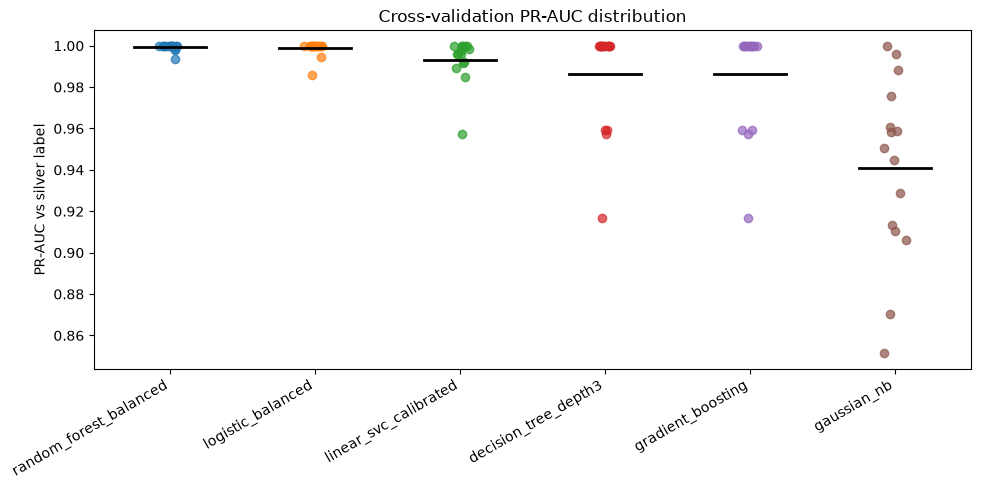

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ordered = cv_result.groupby('model')['pr_auc'].mean().sort_values(ascending=False).index.tolist()
positions = np.arange(len(ordered))

for i, model_name in enumerate(ordered):
    values = cv_result.loc[cv_result['model'] == model_name, 'pr_auc'].values
    jitter = np.random.default_rng(RANDOM_STATE + i).normal(0, 0.04, size=len(values))
    ax.scatter(np.full_like(values, i, dtype=float) + jitter, values, alpha=0.7)
    ax.plot([i - 0.25, i + 0.25], [values.mean(), values.mean()], color='black', linewidth=2)

ax.set_xticks(positions)
ax.set_xticklabels(ordered, rotation=30, ha='right')
ax.set_ylabel('PR-AUC vs silver label')
ax.set_title('Cross-validation PR-AUC distribution')
plt.tight_layout()
plt.show()

## 8. Feature Importance

Permutation importance is computed on the hold-out test set.

A high importance value means that the feature helps reproduce the silver label. It does not prove that the feature is causally related to real viewbot usage.

In [10]:
best_model_name = holdout_result.iloc[0]['model']
best_model = fitted_models[best_model_name]

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring='average_precision',
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False)

print('best hold-out model:', best_model_name)
importance

best hold-out model: logistic_balanced


,feature,importance_mean,importance_std
5,zero_rate,0.8533,0.0142
1,viewer_med,0.0000,0.0000
2,viewer_max,0.0000,0.0000
3,chat_mean,0.0000,0.0000
0,n,0.0000,0.0000
4,unique_mean,0.0000,0.0000
6,zrun_max,0.0000,0.0000
7,gap_med,0.0000,0.0000
8,gap_max,0.0000,0.0000
9,log_viewer,0.0000,0.0000


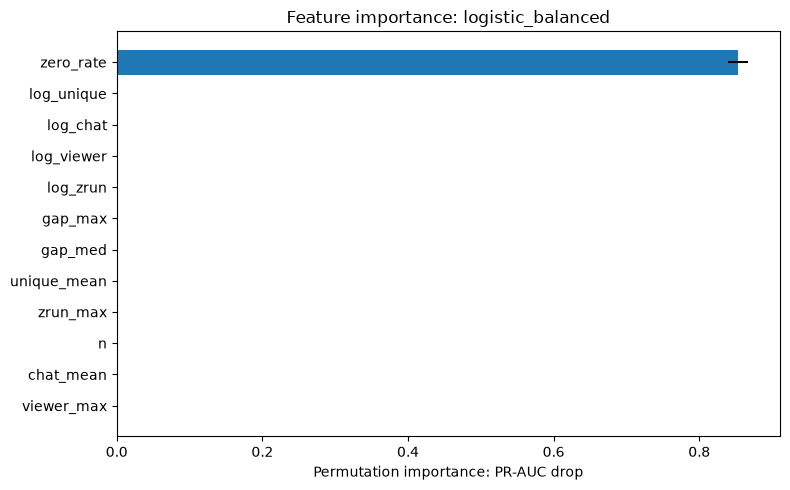

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
imp_plot = importance.sort_values('importance_mean').tail(12)
ax.barh(imp_plot['feature'], imp_plot['importance_mean'], xerr=imp_plot['importance_std'])
ax.set_xlabel('Permutation importance: PR-AUC drop')
ax.set_title(f'Feature importance: {best_model_name}')
plt.tight_layout()
plt.show()

## 9. Decision Tree Rules

The decision tree is included mainly for interpretation. With shallow depth, it gives a compact rule-like summary of how the silver label is separated.

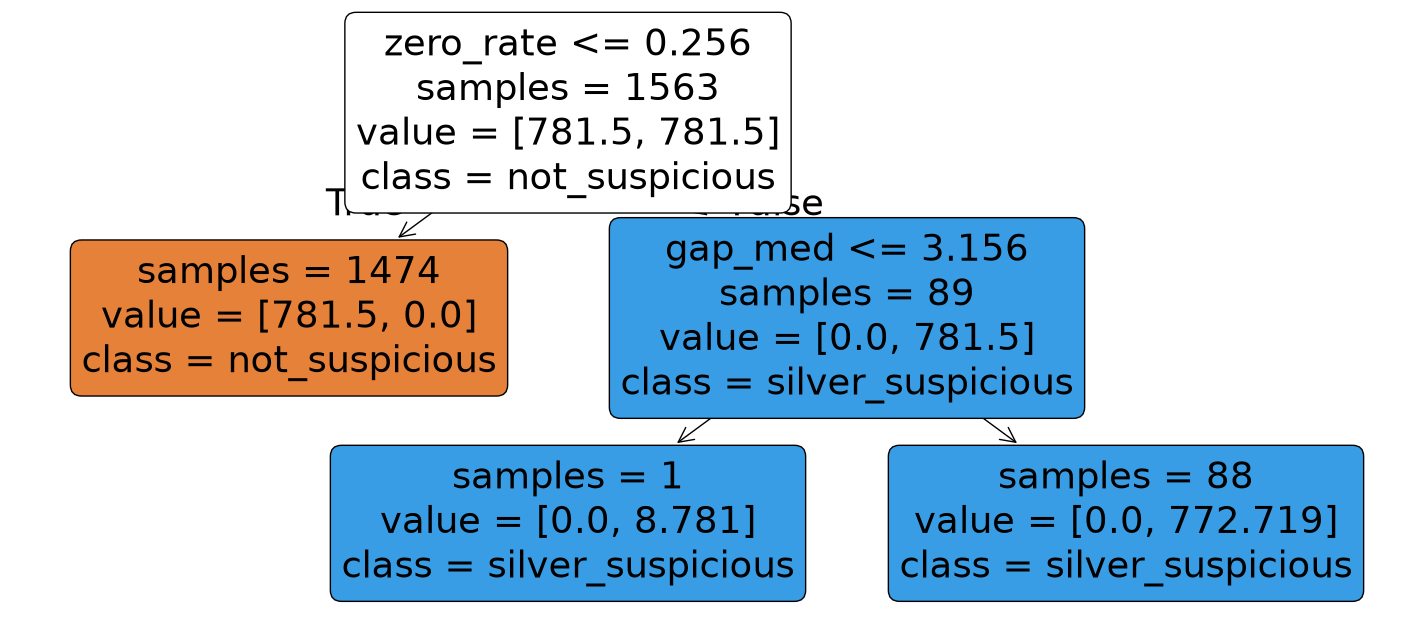

In [12]:
tree_model = fitted_models['decision_tree_depth3']
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(
    tree_model.named_steps['model'],
    feature_names=feature_cols,
    class_names=['not_suspicious', 'silver_suspicious'],
    filled=True,
    rounded=True,
    impurity=False,
    ax=ax,
)
plt.show()

## 10. Save Results

Model comparison tables and feature importance values are saved for presentation and later analysis.

In [13]:
holdout_path = OUTPUT_DIR / '02_holdout_model_comparison.csv'
cv_path = OUTPUT_DIR / '02_cv_model_comparison.csv'
importance_path = OUTPUT_DIR / '02_best_model_permutation_importance.csv'

holdout_result.to_csv(holdout_path, index=False, encoding='utf-8-sig')
cv_result.to_csv(cv_path, index=False, encoding='utf-8-sig')
importance.to_csv(importance_path, index=False, encoding='utf-8-sig')

holdout_path, cv_path, importance_path

(WindowsPath('c:/Users/82103/OneDrive/바탕 화면/SNU_2026-1/데이터마이닝/플젝/최종모델/outputs/02_holdout_model_comparison.csv'),
 WindowsPath('c:/Users/82103/OneDrive/바탕 화면/SNU_2026-1/데이터마이닝/플젝/최종모델/outputs/02_cv_model_comparison.csv'),
 WindowsPath('c:/Users/82103/OneDrive/바탕 화면/SNU_2026-1/데이터마이닝/플젝/최종모델/outputs/02_best_model_permutation_importance.csv'))